
# Segmentación de clientes de Mall con K-Means

**Objetivo:** construir un flujo para segmentar clientes en base a dos variables:
- `Annual Income (k$)`
- `Spending Score (1-100)`

Se aplican dos criterios para seleccionar el número de clusters:
1. **Método del codo** (inercia / SSE).
2. **Coeficiente de silueta**.

Finalmente, se asigna el cluster a cada cliente y se muestra cómo **predecir** el cluster para **nuevos clientes**.


In [4]:

# Paquetes base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# ML
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Reproducibilidad
RANDOM_STATE = 42

# Ruta de datos (ajusta si lo mueves de carpeta)
DATA_PATH = "../data/Mall_Customers.csv"


In [5]:

# Carga del dataset
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())
display(df.describe(include="all"))


Shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000



## 1) Revisión rápida y preparación de variables

Para K-Means, trabajaremos solo con:
- **Annual Income (k$)**
- **Spending Score (1-100)**

> Nota: K-Means es sensible a escala. Aunque ambas variables están en rangos parecidos, aplicaremos **estandarización** (`StandardScaler`) como buena práctica.


In [6]:

features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].copy()

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features usadas:", features)
print("Media (aprox) post-escalado:", X_scaled.mean(axis=0))
print("Desv. estándar (aprox) post-escalado:", X_scaled.std(axis=0))

Features usadas: ['Annual Income (k$)', 'Spending Score (1-100)']
Media (aprox) post-escalado: [-2.13162821e-16 -1.46549439e-16]
Desv. estándar (aprox) post-escalado: [1. 1.]


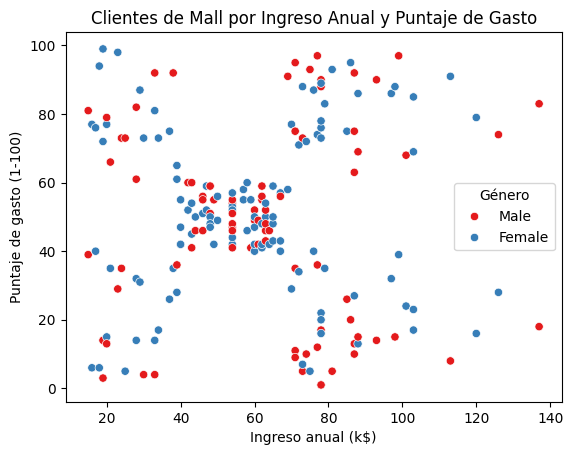

In [33]:

# Visualización 2D de los datos (sin clusters) use 'genre' como color
import seaborn as sns
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Genre', palette='Set1')
plt.title('Clientes de Mall por Ingreso Anual y Puntaje de Gasto')
plt.xlabel('Ingreso anual (k$)')
plt.ylabel('Puntaje de gasto (1-100)')
plt.legend(title='Género')
plt.show()



## 2) Método del codo (Elbow)

Calculamos la **inercia** (SSE) para distintos valores de `k`.  
Buscamos el punto donde el descenso marginal se “aplana” (el “codo”).


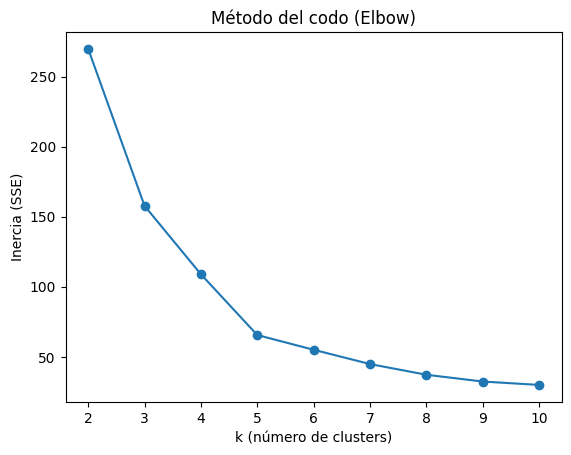

,k,inertia
0,2,269.691012
1,3,157.704008
2,4,108.921317
3,5,65.568408
4,6,55.057348
5,7,44.864756
6,8,37.228188
7,9,32.392268
8,10,29.981898


In [24]:

ks = range(2, 11)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.xticks(list(ks))
plt.xlabel("k (número de clusters)")
plt.ylabel("Inercia (SSE)")
plt.title("Método del codo (Elbow)")
plt.show()

pd.DataFrame({"k": list(ks), "inertia": inertias})



## 3) Coeficiente de silueta

El coeficiente de silueta evalúa simultáneamente:
- **cohesión** dentro del cluster
- **separación** entre clusters

Rango típico: `[-1, 1]` (mientras más cerca de **1**, mejor separación).


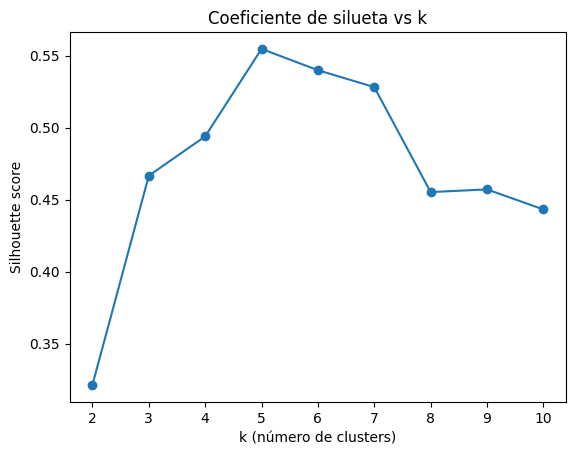

,k,silhouette
3,5,0.554657
4,6,0.539880
5,7,0.528149
2,4,0.493907
1,3,0.466585
7,9,0.457085
6,8,0.455215
8,10,0.443171
0,2,0.321271


In [25]:

sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure()
plt.plot(list(ks), sil_scores, marker="o")
plt.xticks(list(ks))
plt.xlabel("k (número de clusters)")
plt.ylabel("Silhouette score")
plt.title("Coeficiente de silueta vs k")
plt.show()

pd.DataFrame({"k": list(ks), "silhouette": sil_scores}).sort_values("silhouette", ascending=False)



## 4) Selección de k y entrenamiento final

Regla práctica:
- Usar el **codo** para descartar valores muy altos de `k` (sobresegmentación).
- Confirmar con **silueta** buscando máximos o mesetas altas.

En este dataset, suele resultar razonable `k=5` (patrón clásico en este conjunto).
De todos modos, puedes ajustar `K_SELECTED` según lo observado en tus gráficos.


In [26]:

# Selecciona k (ajústalo según tus resultados de elbow + silueta)
K_SELECTED = 5

kmeans = KMeans(n_clusters=K_SELECTED, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered["cluster"] = clusters

display(df_clustered.head())
df_clustered["cluster"].value_counts().sort_index()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

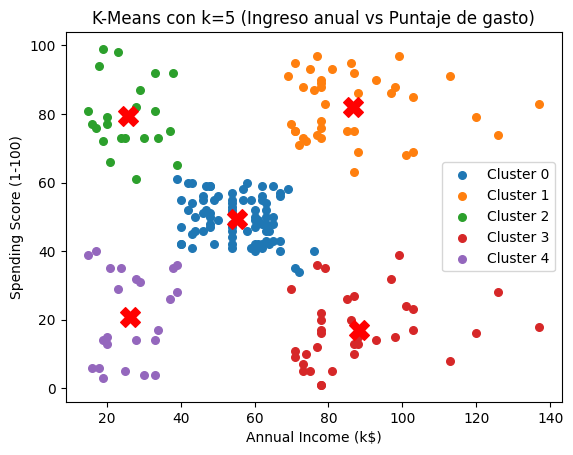

In [34]:

# Visualización de clusters en el espacio original (sin escalar)
plt.figure()
for c in sorted(df_clustered["cluster"].unique()):
    part = df_clustered[df_clustered["cluster"] == c]
    plt.scatter(part[features[0]], part[features[1]], s=30, label=f"Cluster {c}")

# Centroides (en espacio original)
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

plt.scatter(centroids_original[:, 0], centroids_original[:, 1], marker="X", color='red', s=200)
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title(f"K-Means con k={K_SELECTED} (Ingreso anual vs Puntaje de gasto)")
plt.legend()
plt.show()



## 5) Resumen de clusters

Agrupamos por cluster para ver promedios y tamaños de cada segmento.


In [28]:

cluster_profile = (
    df_clustered
    .groupby("cluster")[features + ["Age"]]
    .agg(["count", "mean", "median", "std"])
)

display(cluster_profile)

# Resumen simple
simple_profile = df_clustered.groupby("cluster")[features + ["Age"]].mean()
simple_profile["n"] = df_clustered["cluster"].value_counts().sort_index()
display(simple_profile.sort_values("n", ascending=False))


Annual Income (k$)                               \
                     count       mean median        std   
cluster                                                   
0                       81  55.296296   54.0   8.988109   
1                       39  86.538462   79.0  16.312485   
2                       22  25.727273   24.5   7.566731   
3                       35  88.200000   85.0  16.399067   
4                       23  26.304348   25.0   7.893811   

        Spending Score (1-100)                                Age             \
                         count       mean median        std count       mean   
cluster                                                                        
0                           81  49.518519   50.0   6.530909    81  42.716049   
1                           39  82.128205   83.0   9.364489    39  32.692308   
2                           22  79.363636   77.0  10.504174    22  25.272727   
3                           35  17.114286   16.0   9.952154    35  41.114286   
4                           23  20.913043   17.0  13.017167    23  45.217391   

                           
        median        std  
cluster                    
0         46.0  16.447822  
1         32.0   3.728650  
2         23.5   5.257030  
3         42.0  11.341676  
4         46.0  13.228607

,Annual Income (k$),Spending Score (1-100),Age,n
cluster,,,,
0,55.296296,49.518519,42.716049,81
1,86.538462,82.128205,32.692308,39
3,88.200000,17.114286,41.114286,35
4,26.304348,20.913043,45.217391,23
2,25.727273,79.363636,25.272727,22



## 6) Predicción / asignación de cluster para nuevos clientes

En K-Means, la “predicción” corresponde a **asignar** el cluster cuyo centroide está más cercano.

Importante:
- Debes transformar los nuevos datos con **el mismo `scaler`** entrenado.
- Luego aplicar `kmeans.predict(...)`.


In [29]:

# Ejemplo: nuevos clientes (Annual Income, Spending Score)
new_customers = pd.DataFrame({
    "Annual Income (k$)": [25, 60, 120],
    "Spending Score (1-100)": [80, 45, 20]
})

# Pipeline manual: escalar -> predecir
new_scaled = scaler.transform(new_customers[features])
new_clusters = kmeans.predict(new_scaled)

new_customers_out = new_customers.copy()
new_customers_out["predicted_cluster"] = new_clusters

display(new_customers_out)


,Annual Income (k$),Spending Score (1-100),predicted_cluster
0,25,80,2
1,60,45,0
2,120,20,3



## 7) Exportación opcional

Si necesitas el dataset con clusters para campañas o reporting:
- CSV
- Excel


In [ ]:

# Guardar dataset con cluster (opcional)
df_clustered.to_csv("Mall_Customers_clusters.csv", index=False)

# Para Excel (opcional)
# df_clustered.to_excel("Mall_Customers_clusters.xlsx", index=False)

print("Archivos generados (si ejecutaste esta celda):")
print("- Mall_Customers_clusters.csv")

Archivos generados (si ejecutaste esta celda):
- Mall_Customers_with_clusters.csv



## Conclusiones esperadas

- El dataset suele presentar segmentos claramente separables en el plano **Income vs Spending**.
- **k=5** es una elección común para este dataset (validada con codo + silueta en muchos casos), pero tu reporte debe **justificar** la selección con tus gráficos.
- La asignación de clusters permite campañas diferenciadas (p.ej., alto ingreso-bajo gasto vs alto ingreso-alto gasto, etc.).
